<a href="https://colab.research.google.com/github/adombe/AVCA_2026/blob/main/Assignment_2_Machine_Learning_DEEPSEEK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

prompt: Import all necessary libraries for data manipulation, visualization, and machine learning


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Machine learning
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, KFold, TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

prompt: Use the Petrignano.csv file, handle date parsing, and display basic info




In [2]:
df = pd.read_csv('Petrignano.csv', parse_dates=['Date'], dayfirst=True)
df = df.sort_values('Date').reset_index(drop=True)
print(f"✅ Data loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"\n📅 Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"\nFirst 5 rows:")
print(df.head())
print(f"\nMissing values:")
print(df.isnull().sum())

✅ Data loaded: 4199 rows, 7 columns

📅 Date range: 2009-01-01 00:00:00 to 2020-06-30 00:00:00

First 5 rows:
        Date  Rainfall_Bastia_Umbra  Depth_to_Groundwater_P25  \
0 2009-01-01                    0.0                    -31.14   
1 2009-01-02                    0.0                    -31.11   
2 2009-01-03                    0.0                    -31.07   
3 2009-01-04                    0.0                    -31.05   
4 2009-01-05                    0.0                    -31.01   

   Temperature_Bastia_Umbra  Temperature_Petrignano  Volume_C10_Petrignano  \
0                       5.2                     4.9             -24530.688   
1                       2.3                     2.5             -28785.888   
2                       4.4                     3.9             -25766.208   
3                       0.8                     0.8             -27919.296   
4                      -1.9                    -2.1             -29854.656   

   Hydrometry_Fiume_Chiascio_Pe

prompt: Handle missing values using interpolation for time series data, without destroying valid zeros

In [3]:
print("\n🔧 Handling missing values...")
df_clean = df.copy()

# Check columns with zeros (these are likely valid values)
zero_counts = (df_clean == 0).sum()
print(f"\nColumns with zeros (valid measurements, NOT missing):")
print(zero_counts[zero_counts > 0])

# Only interpolate actual NaN values
df_clean = df_clean.interpolate(method='linear', limit_direction='both')
df_clean = df_clean.bfill().ffill()

print(f"\n✅ Missing values after {{{{imputation}}}}: {df_clean.isnull().sum().sum()}")


🔧 Handling missing values...

Columns with zeros (valid measurements, NOT missing):
Rainfall_Bastia_Umbra                   3147
Temperature_Bastia_Umbra                   7
Temperature_Petrignano                   153
Volume_C10_Petrignano                     25
Hydrometry_Fiume_Chiascio_Petrignano     150
dtype: int64

✅ Missing values after {{imputation}}: 0


prompt: Create lag features: response is Depth_to_Groundwater_P25 at month t, predictors are all variables at t-1 and t-2

In [4]:
print("\n🔧 Creating lag features...")

# The response variable (what we want to predict)
response_col = 'Depth_to_Groundwater_P25'

# Create lagged features for ALL variables (including the response itself - auto-regressive)
variables_to_lag = df_clean.drop(columns=['Date']).columns

# Create shifted versions
for lag in [1, 2]:
    for col in variables_to_lag:
        df_clean[f'{col}_lag{lag}'] = df_clean[col].shift(lag)

# Drop rows with NaN from lag creation
df_clean = df_clean.dropna()

# Define predictors (only lagged variables + optional seasonality)
predictor_cols = [col for col in df_clean.columns if 'lag' in col]
X = df_clean[predictor_cols]
y = df_clean[response_col]

print(f"✅ Created {len(predictor_cols)} predictor features")
print(f"   Feature matrix shape: {X.shape}")
print(f"   Response vector shape: {y.shape}")



🔧 Creating lag features...
✅ Created 12 predictor features
   Feature matrix shape: (4197, 12)
   Response vector shape: (4197,)


prompt: Create time series plot of groundwater depth to understand patterns

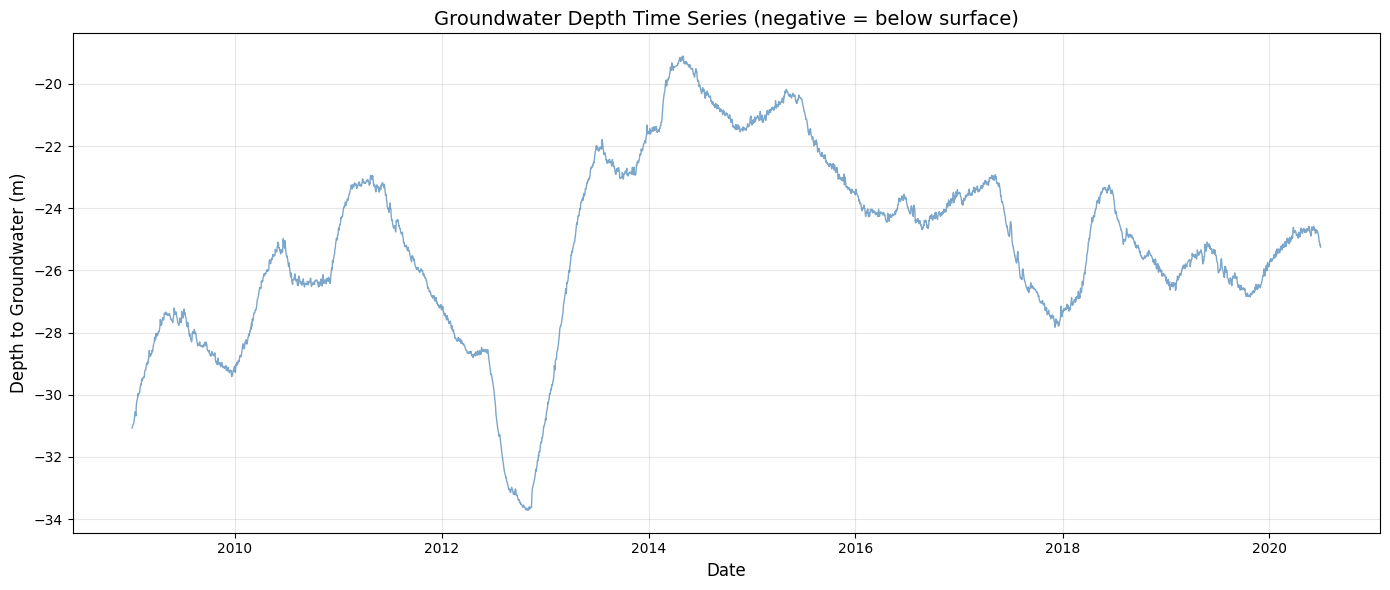


📊 Groundwater depth statistics:
   Min: -33.71 m
   Max: -19.10 m
   Mean: -25.18 m
   Std: 2.95 m


In [5]:
plt.figure(figsize=(14, 6))
plt.plot(df_clean['Date'], y, linewidth=1, alpha=0.7, color='steelblue')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Depth to Groundwater (m)', fontsize=12)
plt.title('Groundwater Depth Time Series (negative = below surface)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 Groundwater depth statistics:")
print(f"   Min: {y.min():.2f} m")
print(f"   Max: {y.max():.2f} m")
print(f"   Mean: {y.mean():.2f} m")
print(f"   Std: {y.std():.2f} m")

prompt: Split data chronologically: 80% training (past), 20% testing (future)

In [6]:
print("\n🔧 Creating train/test split...")

# IMPORTANT: shuffle=False preserves time order!
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False, random_state=42
)

print(f"✅ Training period: {df_clean['Date'].iloc[:len(X_train)].min()} to {df_clean['Date'].iloc[:len(X_train)].max()}")
print(f"   Training samples: {len(X_train)}")
print(f"✅ Test period: {df_clean['Date'].iloc[-len(X_test):].min()} to {df_clean['Date'].iloc[-len(X_test):].max()}")
print(f"   Test samples: {len(X_test)}")


🔧 Creating train/test split...
✅ Training period: 2009-01-03 00:00:00 to 2018-03-13 00:00:00
   Training samples: 3357
✅ Test period: 2018-03-14 00:00:00 to 2020-06-30 00:00:00
   Test samples: 840


prompt: Define KFold (shuffled - CAUSES LEAKAGE) and TimeSeriesSplit (temporal - HONEST)

In [7]:
print("\n🔧 Defining {{{{cross-validation}}}} strategies...")

# NAIVE: Shuffles data - this causes {{{{data leakage}}}!
cv_naive = KFold(n_splits=5, shuffle=True, random_state=42)

# TEMPORAL: Respects time order - trains on past, validates on future
cv_temporal = TimeSeriesSplit(n_splits=5)

print(f"✅ Naive KFold: {cv_naive}")
print(f"   ⚠️  WARNING: Shuffling mixes past and future - causes data leakage!")
print(f"\n✅ TimeSeriesSplit: {cv_temporal}")
print(f"   ✅ Respects temporal order - each fold trains on past, validates on future")

# Display folds structure
print(f"\n📁 Temporal {{{{folds}}}} structure:")
for i, (train_idx, val_idx) in enumerate(cv_temporal.split(X_train)):
    print(f"   Fold {i+1}: Train {len(train_idx)} samples, Validate {len(val_idx)} samples")


🔧 Defining {{{{cross-validation}}}} strategies...
✅ Naive KFold: KFold(n_splits=5, random_state=42, shuffle=True)
   ⚠️  WARNING: Shuffling mixes past and future - causes data leakage!

✅ TimeSeriesSplit: TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None)
   ✅ Respects temporal order - each fold trains on past, validates on future

📁 Temporal {{folds}} structure:
   Fold 1: Train 562 samples, Validate 559 samples
   Fold 2: Train 1121 samples, Validate 559 samples
   Fold 3: Train 1680 samples, Validate 559 samples
   Fold 4: Train 2239 samples, Validate 559 samples
   Fold 5: Train 2798 samples, Validate 559 samples


prompt: Train a fixed DecisionTreeRegressor with both CV strategies and compare results

In [8]:
print("\n" + "="*70)
print("SECTION 1: FIXED MODEL COMPARISON (max_depth=10)")
print("="*70)

# Create pipeline
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', DecisionTreeRegressor(max_depth=10, random_state=42))
])

# Naive CV (with leakage)
scores_naive = cross_val_score(pipe, X_train, y_train, cv=cv_naive, scoring='r2')
print(f"\n📊 Naive KFold (shuffled):")
print(f"   Individual fold R2 scores: {scores_naive}")
print(f"   Mean R2: {scores_naive.mean():.4f} (+/- {scores_naive.std():.4f})")

# Temporal CV (honest)
scores_temporal = cross_val_score(pipe, X_train, y_train, cv=cv_temporal, scoring='r2')
print(f"\n📊 TimeSeriesSplit (sequential):")
print(f"   Individual fold R2 scores: {scores_temporal}")
print(f"   Mean R2: {scores_temporal.mean():.4f} (+/- {scores_temporal.std():.4f})")

# Train on all training, test on future holdout
pipe.fit(X_train, y_train)
y_pred_test = pipe.predict(X_test)
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)

print(f"\n📊 Independent Test Set (Future Data):")
print(f"   Test R2: {test_r2:.4f}")
print(f"   Test MAE: {test_mae:.4f} meters")

print(f"\n💡 KEY INSIGHT:")
print(f"   Gap (Naive CV - Test): {scores_naive.mean() - test_r2:.4f}")
print(f"   Gap (Temporal CV - Test): {scores_temporal.mean() - test_r2:.4f}")
print(f"   → Shuffled CV overestimates performance by {scores_naive.mean() - test_r2:.4f} R2 points!")



SECTION 1: FIXED MODEL COMPARISON (max_depth=10)

📊 Naive KFold (shuffled):
   Individual fold R2 scores: [0.99940552 0.99935315 0.99943085 0.99937455 0.99933132]
   Mean R2: 0.9994 (+/- 0.0000)

📊 TimeSeriesSplit (sequential):
   Individual fold R2 scores: [ 0.49037595  0.91271599 -0.32261654  0.99374685  0.9969666 ]
   Mean R2: 0.6142 (+/- 0.5045)

📊 Independent Test Set (Future Data):
   Test R2: 0.9849
   Test MAE: 0.0802 meters

💡 KEY INSIGHT:
   Gap (Naive CV - Test): 0.0145
   Gap (Temporal CV - Test): -0.3706
   → Shuffled CV overestimates performance by 0.0145 R2 points!


prompt: Create function for model selection using GridSearchCV with hyperparameters


In [9]:
def evaluate_model_selection(X_train, y_train, X_test, y_test, cv_strategy, name):
    """
    Perform {{{{model selection}}}} with hyperparameter tuning for a given CV strategy.

    Parameters:
    - X_train, y_train: Training data
    - X_test, y_test: Independent test data (future holdout)
    - cv_strategy: Cross-validation strategy (KFold or TimeSeriesSplit)
    - name: Name for printing results

    Returns:
    - grid: Fitted GridSearchCV object
    """

    # Step A: Create pipeline with imputer, scaler, and regressor
    pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),  # Safety for any remaining NaNs
        ('scaler', StandardScaler()),
        ('regressor', DecisionTreeRegressor(random_state=42))
    ])

    # Step B: Define hyperparameter grid
    # Try different tree depths and splitting criteria to prevent overfitting
    param_grid = {
        'regressor__max_depth': [5, 10, 15, 20, 25, 30],
        'regressor__min_samples_split': [2, 5, 10],
        'regressor__min_samples_leaf': [1, 2, 4]
    }

    # Step C: Grid search with cross-validation
    print(f"\n🔄 Searching {{{{hyper parameters}}}} for {name}...")
    grid = GridSearchCV(
        estimator=pipe,
        param_grid=param_grid,
        cv=cv_strategy,
        scoring='r2',
        n_jobs=-1,  # Use all CPU cores
        verbose=0    # Set to 1 to see progress
    )

    grid.fit(X_train, y_train)

    # Step D: Evaluate on independent test set
    y_pred = grid.predict(X_test)
    test_r2 = r2_score(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    # Print results
    print(f"\n{'='*60}")
    print(f"RESULTS: {name}")
    print(f"{'='*60}")
    print(f"Best {{{{hyper parameters}}}}: {grid.best_params_}")
    print(f"Internal CV Score (R2): {grid.best_score_:.4f}")
    print(f"Independent Test Score (R2): {test_r2:.4f}")
    print(f"Test MAE: {test_mae:.4f} m")
    print(f"Test RMSE: {test_rmse:.4f} m")

    # Calculate overfitting gap
    gap = grid.best_score_ - test_r2
    if gap > 0:
        print(f"\n⚠️  Gap (CV - Test): {gap:.4f} (overfitting)")
    else:
        print(f"\n✅ Gap (CV - Test): {gap:.4f} (good generalization)")

    return grid

prompt: Execute model selection with both CV strategies and compare results


In [10]:
print("\n" + "="*70)
print("SECTION 2: MODEL SELECTION COMPARISON")
print("="*70)

# Run with Naive K-Fold (shuffled - has data leakage)
result_naive = evaluate_model_selection(
    X_train, y_train, X_test, y_test,
    cv_naive, "Naive K-Fold (with data leakage)"
)

# Run with TimeSeriesSplit (temporal - honest evaluation)
result_temporal = evaluate_model_selection(
    X_train, y_train, X_test, y_test,
    cv_temporal, "TimeSeriesSplit (no leakage)"
)


SECTION 2: MODEL SELECTION COMPARISON

🔄 Searching {{hyper parameters}} for Naive K-Fold (with data leakage)...

RESULTS: Naive K-Fold (with data leakage)
Best {{hyper parameters}}: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 2}
Internal CV Score (R2): 0.9994
Independent Test Score (R2): 0.9892
Test MAE: 0.0684 m
Test RMSE: 0.0884 m

⚠️  Gap (CV - Test): 0.0102 (overfitting)

🔄 Searching {{hyper parameters}} for TimeSeriesSplit (no leakage)...

RESULTS: TimeSeriesSplit (no leakage)
Best {{hyper parameters}}: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2}
Internal CV Score (R2): 0.6142
Independent Test Score (R2): 0.9849
Test MAE: 0.0802 m
Test RMSE: 0.1046 m

✅ Gap (CV - Test): -0.3706 (good generalization)


prompt: Create comparison plots for both models' predictions on test data


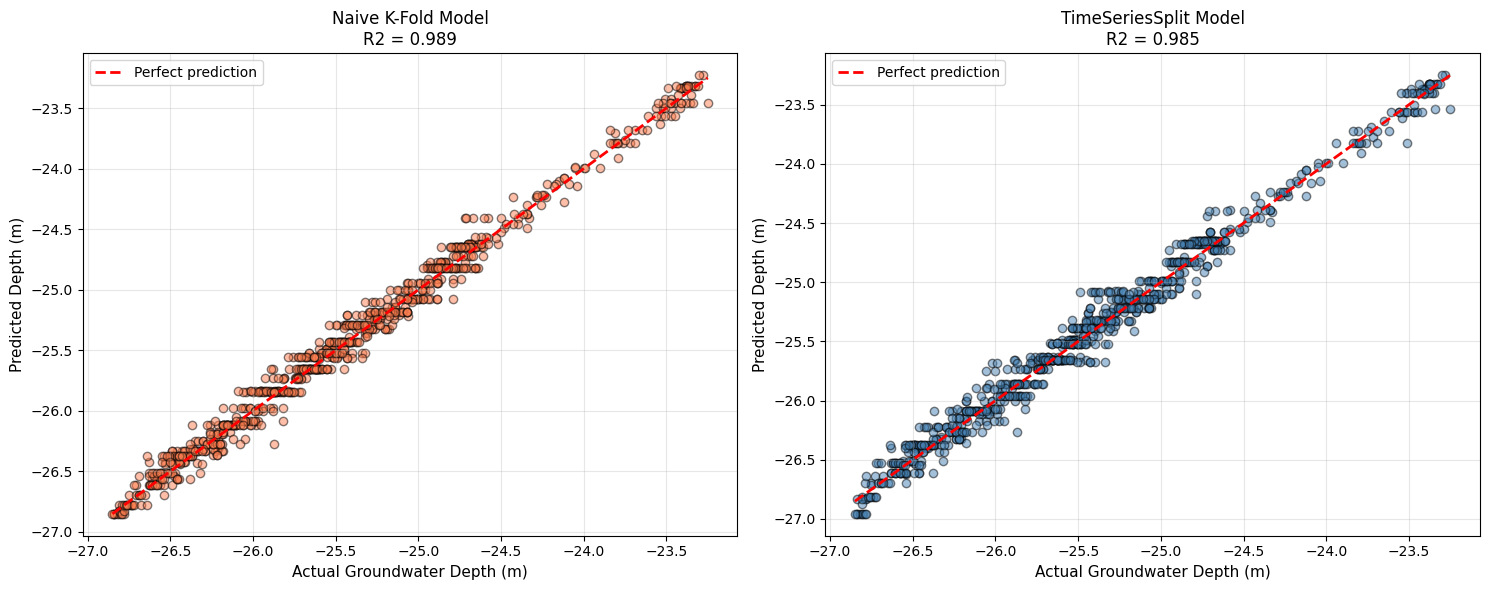

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Scatter plot - Naive model
y_pred_naive = result_naive.predict(X_test)
axes[0].scatter(y_test, y_pred_naive, alpha=0.5, edgecolors='k', c='coral')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('Actual Groundwater Depth (m)', fontsize=11)
axes[0].set_ylabel('Predicted Depth (m)', fontsize=11)
axes[0].set_title(f'Naive K-Fold Model\nR2 = {r2_score(y_test, y_pred_naive):.3f}', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Scatter plot - Temporal model
y_pred_temporal = result_temporal.predict(X_test)
axes[1].scatter(y_test, y_pred_temporal, alpha=0.5, edgecolors='k', c='steelblue')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('Actual Groundwater Depth (m)', fontsize=11)
axes[1].set_ylabel('Predicted Depth (m)', fontsize=11)
axes[1].set_title(f'TimeSeriesSplit Model\nR2 = {r2_score(y_test, y_pred_temporal):.3f}', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


prompt: Plot actual vs predicted values over time for both models

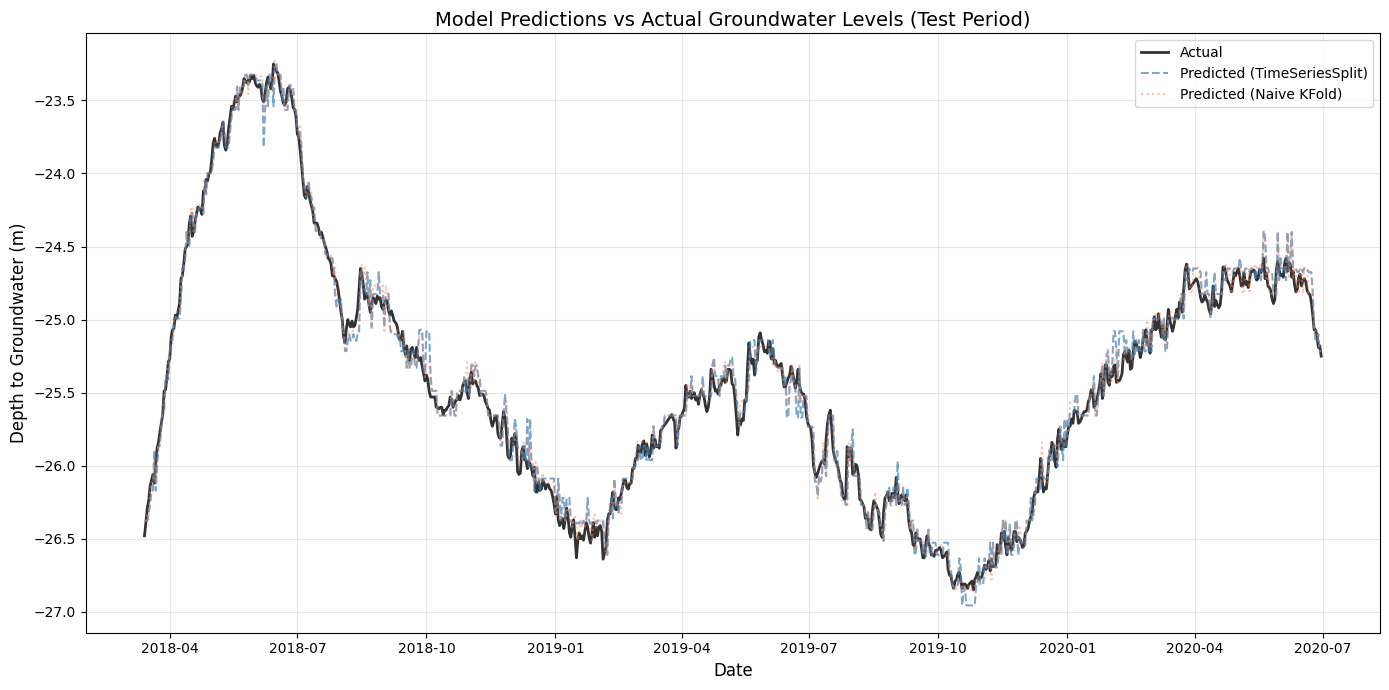

In [12]:
plt.figure(figsize=(14, 7))
test_dates = df_clean['Date'].iloc[-len(X_test):]

plt.plot(test_dates, y_test, label='Actual', linewidth=2, alpha=0.8, color='black')
plt.plot(test_dates, y_pred_temporal, label='Predicted (TimeSeriesSplit)',
         linewidth=1.5, alpha=0.7, linestyle='--', color='steelblue')
plt.plot(test_dates, y_pred_naive, label='Predicted (Naive KFold)',
         linewidth=1.5, alpha=0.5, linestyle=':', color='coral')

plt.xlabel('Date', fontsize=12)
plt.ylabel('Depth to Groundwater (m)', fontsize=12)
plt.title('Model Predictions vs Actual Groundwater Levels (Test Period)', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

prompt: Create summary table comparing both approaches

In [13]:
print("\n" + "="*70)
print("FINAL SUMMARY: NAIVE K-FOLD vs TIMESERIESSPLIT")
print("="*70)

summary_data = {
    'Metric': [
        'Best Hyperparameters',
        'Internal CV R2',
        'Independent Test R2',
        'CV-Test Gap (Overfitting)',
        'Test MAE (meters)',
        'Test RMSE (meters)'
    ],
    'Naive K-Fold (shuffled)': [
        str(result_naive.best_params_),
        f"{result_naive.best_score_:.4f}",
        f"{r2_score(y_test, result_naive.predict(X_test)):.4f}",
        f"{result_naive.best_score_ - r2_score(y_test, result_naive.predict(X_test)):.4f}",
        f"{mean_absolute_error(y_test, result_naive.predict(X_test)):.4f}",
        f"{np.sqrt(mean_squared_error(y_test, result_naive.predict(X_test))):.4f}"
    ],
    'TimeSeriesSplit (sequential)': [
        str(result_temporal.best_params_),
        f"{result_temporal.best_score_:.4f}",
        f"{r2_score(y_test, result_temporal.predict(X_test)):.4f}",
        f"{result_temporal.best_score_ - r2_score(y_test, result_temporal.predict(X_test)):.4f}",
        f"{mean_absolute_error(y_test, result_temporal.predict(X_test)):.4f}",
        f"{np.sqrt(mean_squared_error(y_test, result_temporal.predict(X_test))):.4f}"
    ]
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


FINAL SUMMARY: NAIVE K-FOLD vs TIMESERIESSPLIT
                   Metric                                                                           Naive K-Fold (shuffled)                                                                      TimeSeriesSplit (sequential)
     Best Hyperparameters {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 4, 'regressor__min_samples_split': 2} {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2}
           Internal CV R2                                                                                            0.9994                                                                                            0.6142
      Independent Test R2                                                                                            0.9892                                                                                            0.9849
CV-Test Gap (Overfitting)                                       